In [1]:
# ============================================================
# 05_publication_figures.ipynb
# Updated figures for the homology-aware revised pipeline
# ===========================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:

import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D

# ---------- Project paths ----------
PROJECT_ROOT = "/content/drive/MyDrive/atlas-go-revision"
CONFIG_PATH = f"{PROJECT_ROOT}/configs/config.yaml"

with open(CONFIG_PATH, "r") as file:
    cfg = yaml.safe_load(file)

TABLES_DIR = cfg["paths"]["results"]
FIGURES_DIR = cfg["paths"]["figures"]

os.makedirs(FIGURES_DIR, exist_ok=True)

# ---------- Publication style ----------
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.linewidth": 1.1,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FEATURE_ORDER = ["P", "PS", "PSD", "E", "ES", "ESD", "PE", "PES", "PESD"]
ARCH_ORDER = ["MLP", "CNN1D", "ResFFN"]

ARCH_COLORS = {
    "MLP": "#4472C4",
    "CNN1D": "#70AD47",
    "ResFFN": "#ED7D31",
}

FEATURE_GROUP_COLORS = {
    "ProtBERT-based": "#4C78A8",
    "ESM2-based": "#59A14F",
    "Combined": "#9C6ADE",
}

STATIC_FEATURE_NAMES = ["α%", "β%", "Coil%", "Length"]


def save_figure(fig, filename):
    """Save each figure as PNG and editable PDF."""
    png_path = f"{FIGURES_DIR}/{filename}.png"
    pdf_path = f"{FIGURES_DIR}/{filename}.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


# ---------- Load final outputs ----------
results = pd.read_csv(
    f"{TABLES_DIR}/full_results_homology_mean_sd_ci.csv"
)

per_seed = pd.read_csv(
    f"{TABLES_DIR}/per_seed_results_homology.csv"
)

baseline = pd.read_csv(
    f"{TABLES_DIR}/continuous_frequency_baseline_homology.csv"
)

dynamic_tests = pd.read_csv(
    f"{TABLES_DIR}/dynamic_feature_matched_tests_homology.csv"
)

term_prevalence = pd.read_csv(
    f"{TABLES_DIR}/test_term_prevalence_homology.csv"
)

xai_group = pd.read_csv(
    f"{TABLES_DIR}/xai_integrated_gradients_group_results.csv"
)

xai_feature = pd.read_csv(
    f"{TABLES_DIR}/xai_per_feature_integrated_gradients.csv"
)

xai_permutation = pd.read_csv(
    f"{TABLES_DIR}/xai_permutation_importance.csv"
)

xai_lomo = pd.read_csv(
    f"{TABLES_DIR}/xai_leave_one_modality_out.csv"
)

xai_wilcoxon = pd.read_csv(
    f"{TABLES_DIR}/xai_group_wilcoxon_tests.csv"
)

baseline_fmax = float(baseline.loc[0, "Overall_Fmax"])
baseline_auprc = float(baseline.loc[0, "Overall_AUPRC"])

# Select the best configuration per architecture using validation only.
best_indices = results.groupby(
    "Architecture"
)["Validation_best_Fmax_mean"].idxmax()

best_by_arch = (
    results.loc[best_indices]
    .set_index("Architecture")
    .reindex(ARCH_ORDER)
    .reset_index()
)

print("Loaded final revised-pipeline result tables.")
display(best_by_arch[
    [
        "Architecture",
        "Feature",
        "Overall_Fmax_mean",
        "Overall_Fmax_std",
        "Overall_AUPRC_mean",
        "Validation_best_Fmax_mean",
    ]
])

Loaded final revised-pipeline result tables.


,Architecture,Feature,Overall_Fmax_mean,Overall_Fmax_std,Overall_AUPRC_mean,Validation_best_Fmax_mean
0,MLP,PES,0.468456,0.011510,0.297244,0.497722
1,CNN1D,ESD,0.439203,0.023071,0.219989,0.446895
2,ResFFN,PES,0.465435,0.018592,0.283609,0.497308


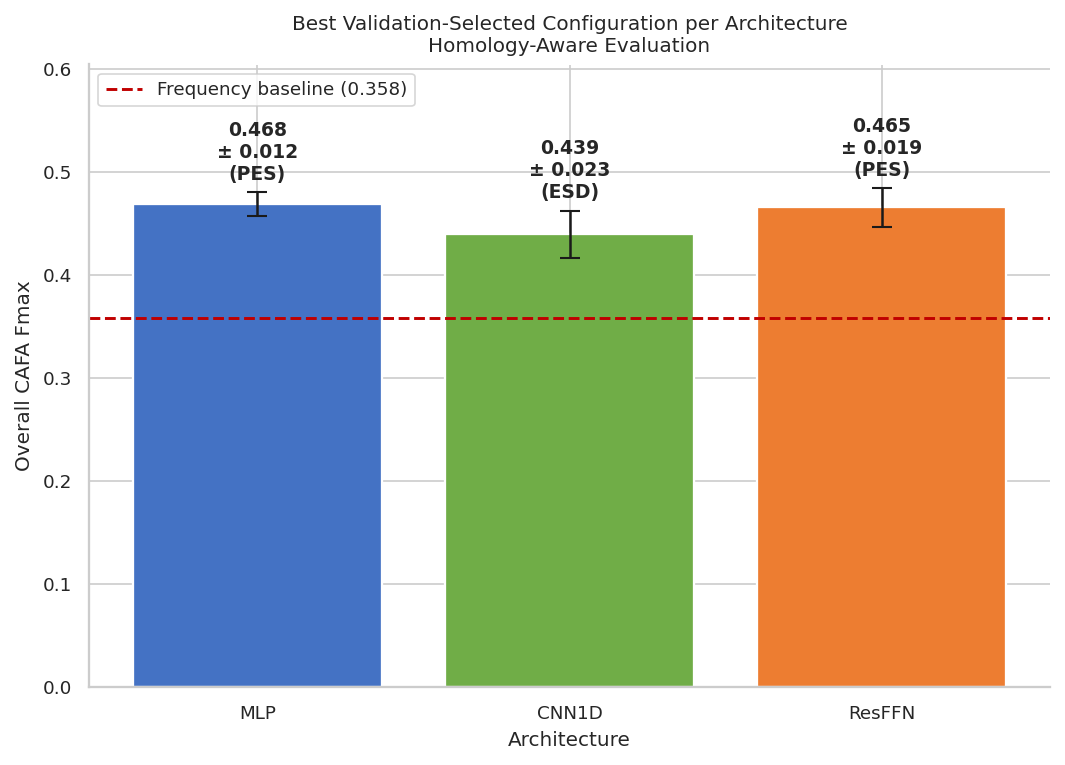

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig1_best_architecture_comparison.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig1_best_architecture_comparison.pdf


In [3]:
# ============================================================
# Figure 1 — Best validation-selected model per architecture
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 5.2))

x = np.arange(len(best_by_arch))

bars = ax.bar(
    x=x,
    height=best_by_arch["Overall_Fmax_mean"],
    yerr=best_by_arch["Overall_Fmax_std"],
    capsize=5,
    color=[ARCH_COLORS[a] for a in best_by_arch["Architecture"]],
    edgecolor="white",
    linewidth=1.1,
)

for bar, (_, row) in zip(bars, best_by_arch.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row["Overall_Fmax_std"] + 0.008,
        f"{row['Overall_Fmax_mean']:.3f}\n± {row['Overall_Fmax_std']:.3f}\n({row['Feature']})",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.axhline(
    baseline_fmax,
    color="#C00000",
    linestyle="--",
    linewidth=1.4,
    label=f"Frequency baseline ({baseline_fmax:.3f})",
)

ax.set_xticks(x)
ax.set_xticklabels(best_by_arch["Architecture"])
ax.set_ylabel("Overall CAFA Fmax")
ax.set_xlabel("Architecture")
ax.set_title(
    "Best Validation-Selected Configuration per Architecture\n"
    "Homology-Aware Evaluation"
)
ax.set_ylim(0, max(best_by_arch["Overall_Fmax_mean"] + best_by_arch["Overall_Fmax_std"]) + 0.12)
ax.legend(frameon=True, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_figure(fig, "Fig1_best_architecture_comparison")

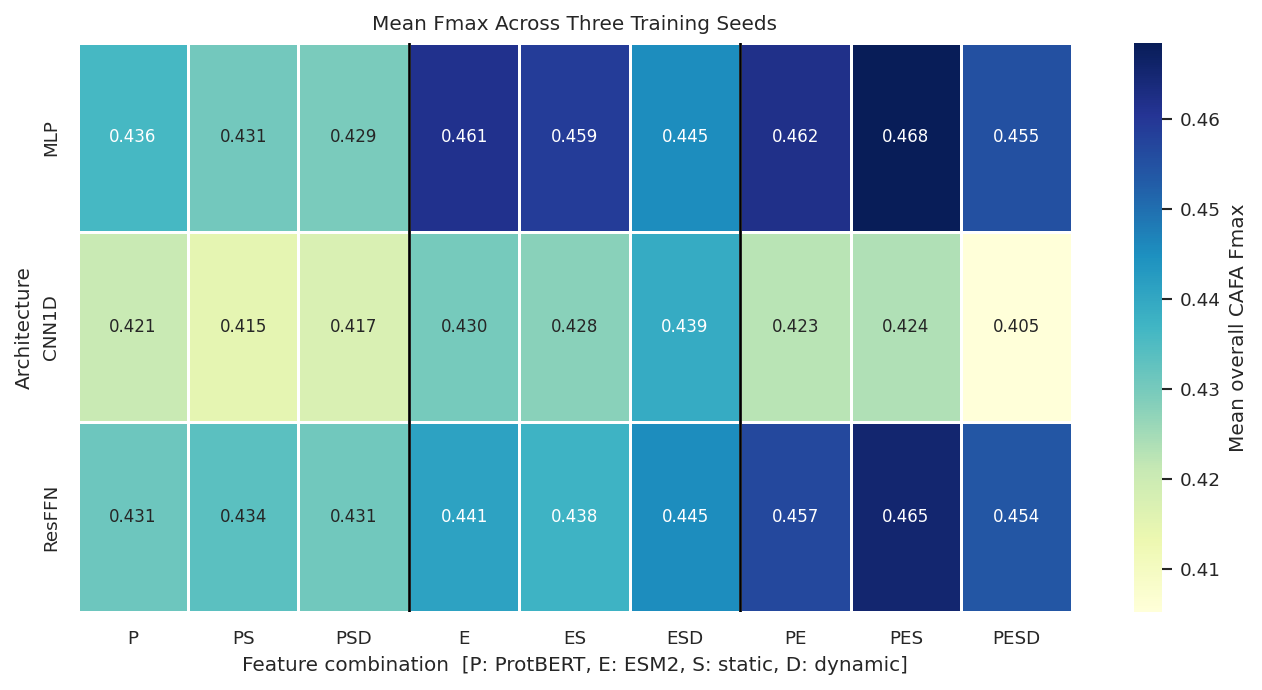

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig2_feature_ablation_heatmap.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig2_feature_ablation_heatmap.pdf


In [4]:
# ============================================================
# Figure 2 — Mean Fmax heatmap for all 27 configurations
# ============================================================

heatmap_data = (
    results
    .pivot(index="Architecture", columns="Feature", values="Overall_Fmax_mean")
    .reindex(index=ARCH_ORDER, columns=FEATURE_ORDER)
)

fig, ax = plt.subplots(figsize=(9, 4.7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean overall CAFA Fmax"},
    annot_kws={"fontsize": 8},
    ax=ax,
)

ax.axvline(3, color="black", linewidth=1.3)
ax.axvline(6, color="black", linewidth=1.3)

ax.set_xlabel("Feature combination  [P: ProtBERT, E: ESM2, S: static, D: dynamic]")
ax.set_ylabel("Architecture")
ax.set_title("Mean Fmax Across Three Training Seeds")

fig.tight_layout()
save_figure(fig, "Fig2_feature_ablation_heatmap")

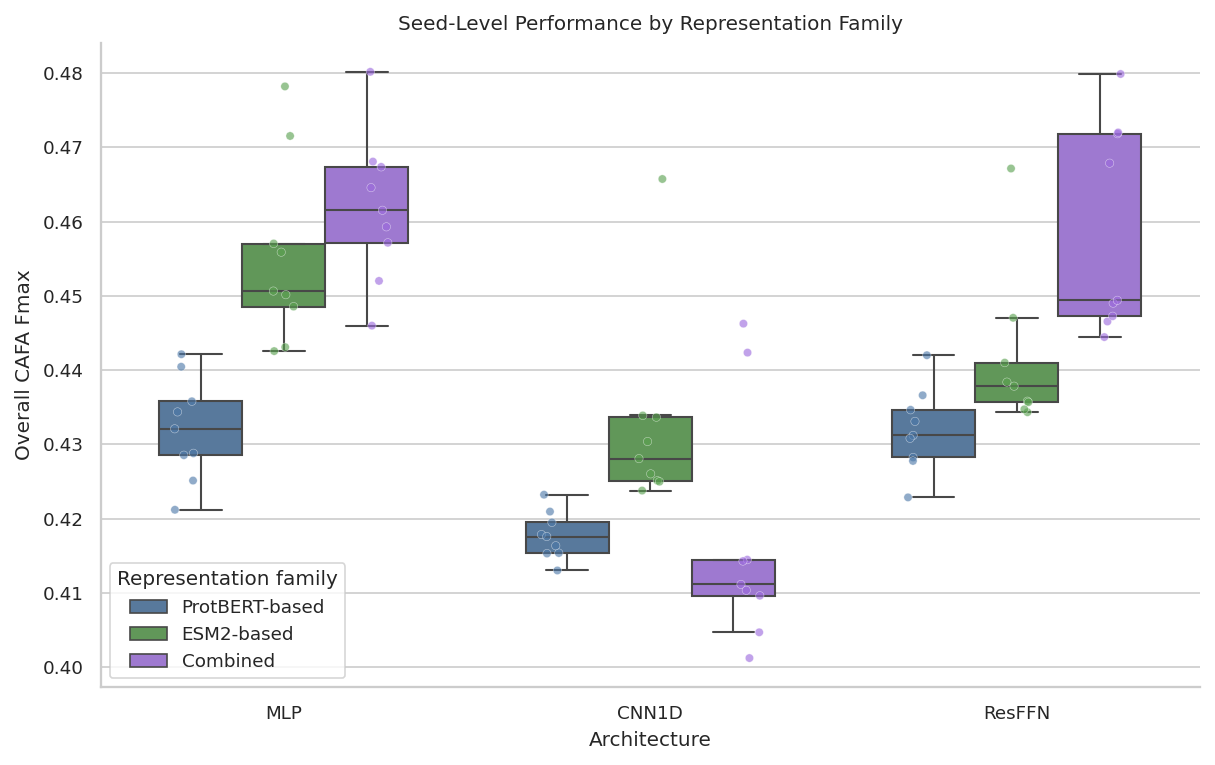

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig3_representation_family_comparison.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig3_representation_family_comparison.pdf


In [5]:
# ============================================================
# Figure 3 — ESM2-based versus ProtBERT-based representations
# Individual dots are individual seed-level runs.
# ============================================================

comparison = per_seed.copy()

comparison["Feature_family"] = np.select(
    [
        comparison["Feature"].isin(["P", "PS", "PSD"]),
        comparison["Feature"].isin(["E", "ES", "ESD"]),
        comparison["Feature"].isin(["PE", "PES", "PESD"]),
    ],
    [
        "ProtBERT-based",
        "ESM2-based",
        "Combined",
    ],
    default="Other",
)

fig, ax = plt.subplots(figsize=(8.2, 5.2))

sns.boxplot(
    data=comparison,
    x="Architecture",
    y="Overall_Fmax",
    hue="Feature_family",
    order=ARCH_ORDER,
    hue_order=["ProtBERT-based", "ESM2-based", "Combined"],
    palette=FEATURE_GROUP_COLORS,
    width=0.68,
    fliersize=0,
    ax=ax,
)

sns.stripplot(
    data=comparison,
    x="Architecture",
    y="Overall_Fmax",
    hue="Feature_family",
    order=ARCH_ORDER,
    hue_order=["ProtBERT-based", "ESM2-based", "Combined"],
    palette=FEATURE_GROUP_COLORS,
    dodge=True,
    alpha=0.62,
    size=4,
    linewidth=0.25,
    edgecolor="white",
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:3],
    labels[:3],
    title="Representation family",
    frameon=True,
)

ax.set_xlabel("Architecture")
ax.set_ylabel("Overall CAFA Fmax")
ax.set_title("Seed-Level Performance by Representation Family")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_figure(fig, "Fig3_representation_family_comparison")

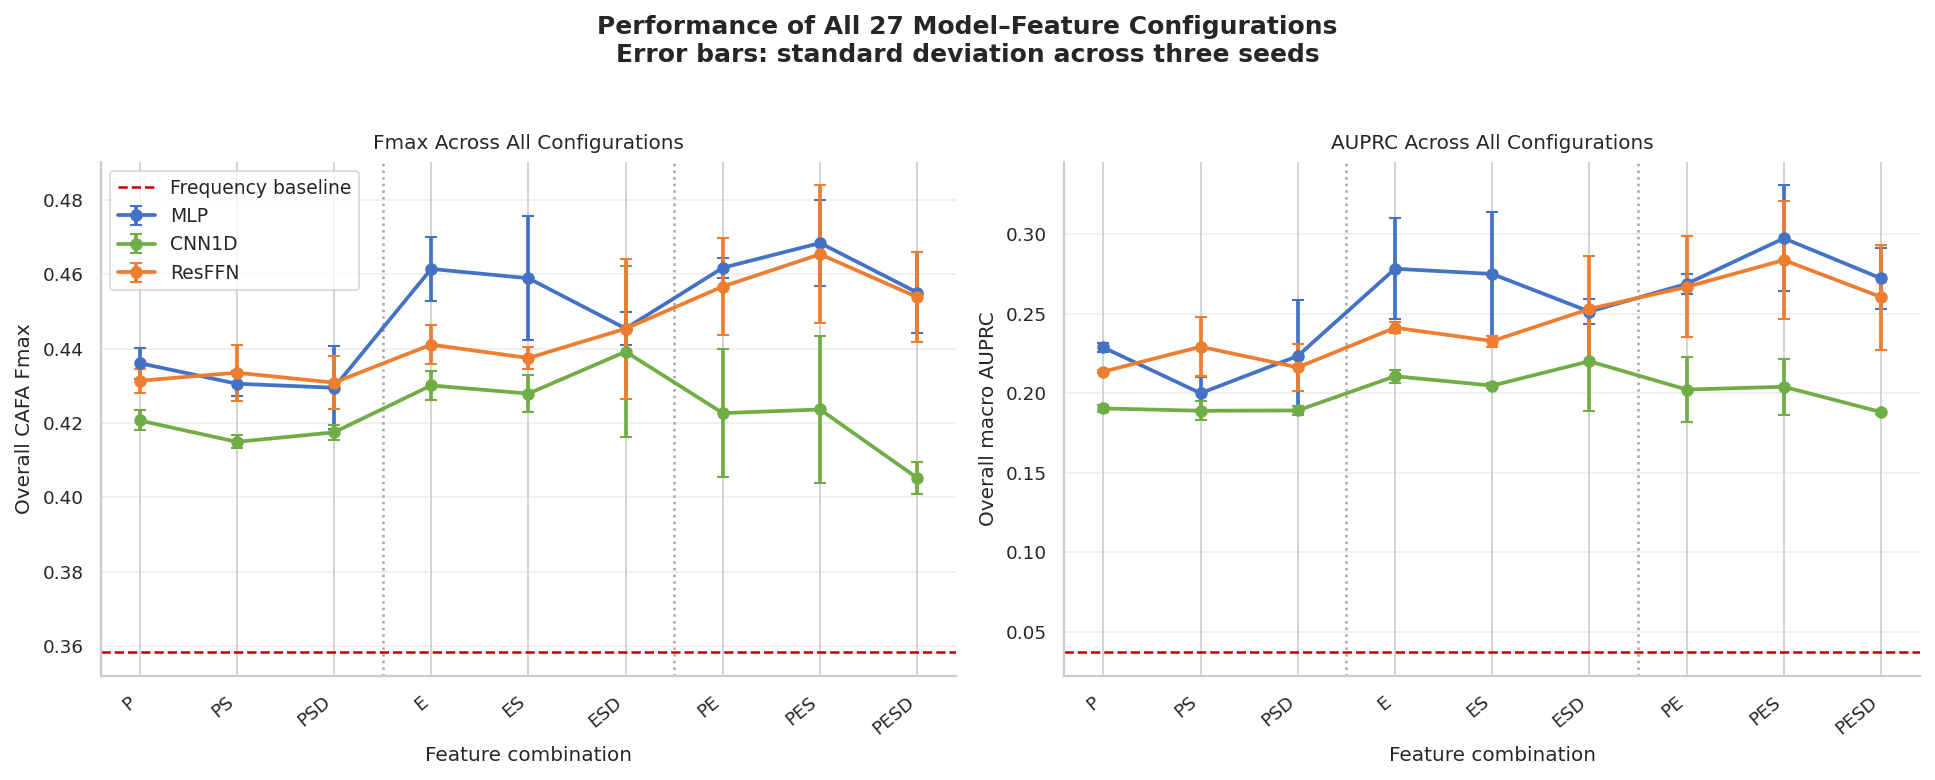

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig4_fmax_auprc_all_configurations.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig4_fmax_auprc_all_configurations.pdf


In [6]:
# ============================================================
# Figure 4 — Fmax and AUPRC for all 27 configurations
# Error bars show standard deviation over the three seeds.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

metrics = [
    (
        "Overall_Fmax_mean",
        "Overall_Fmax_std",
        baseline_fmax,
        "Overall CAFA Fmax",
        "Fmax",
    ),
    (
        "Overall_AUPRC_mean",
        "Overall_AUPRC_std",
        baseline_auprc,
        "Overall macro AUPRC",
        "AUPRC",
    ),
]

for ax, (mean_col, std_col, baseline_value, ylabel, title_metric) in zip(axes, metrics):

    for architecture in ARCH_ORDER:
        subset = (
            results[results["Architecture"] == architecture]
            .set_index("Feature")
            .reindex(FEATURE_ORDER)
            .reset_index()
        )

        ax.errorbar(
            x=np.arange(len(FEATURE_ORDER)),
            y=subset[mean_col],
            yerr=subset[std_col],
            color=ARCH_COLORS[architecture],
            marker="o",
            markersize=5,
            linewidth=1.8,
            capsize=3,
            label=architecture,
        )

    ax.axhline(
        baseline_value,
        color="#C00000",
        linestyle="--",
        linewidth=1.2,
        label="Frequency baseline",
    )

    ax.set_xticks(np.arange(len(FEATURE_ORDER)))
    ax.set_xticklabels(FEATURE_ORDER, rotation=40, ha="right")
    ax.set_xlabel("Feature combination")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title_metric} Across All Configurations")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.35)

    ax.axvline(2.5, color="gray", linestyle=":", alpha=0.7)
    ax.axvline(5.5, color="gray", linestyle=":", alpha=0.7)

axes[0].legend(frameon=True, fontsize=9)

fig.suptitle(
    "Performance of All 27 Model–Feature Configurations\n"
    "Error bars: standard deviation across three seeds",
    y=1.03,
    fontsize=12,
    fontweight="bold",
)

fig.tight_layout()
save_figure(fig, "Fig4_fmax_auprc_all_configurations")

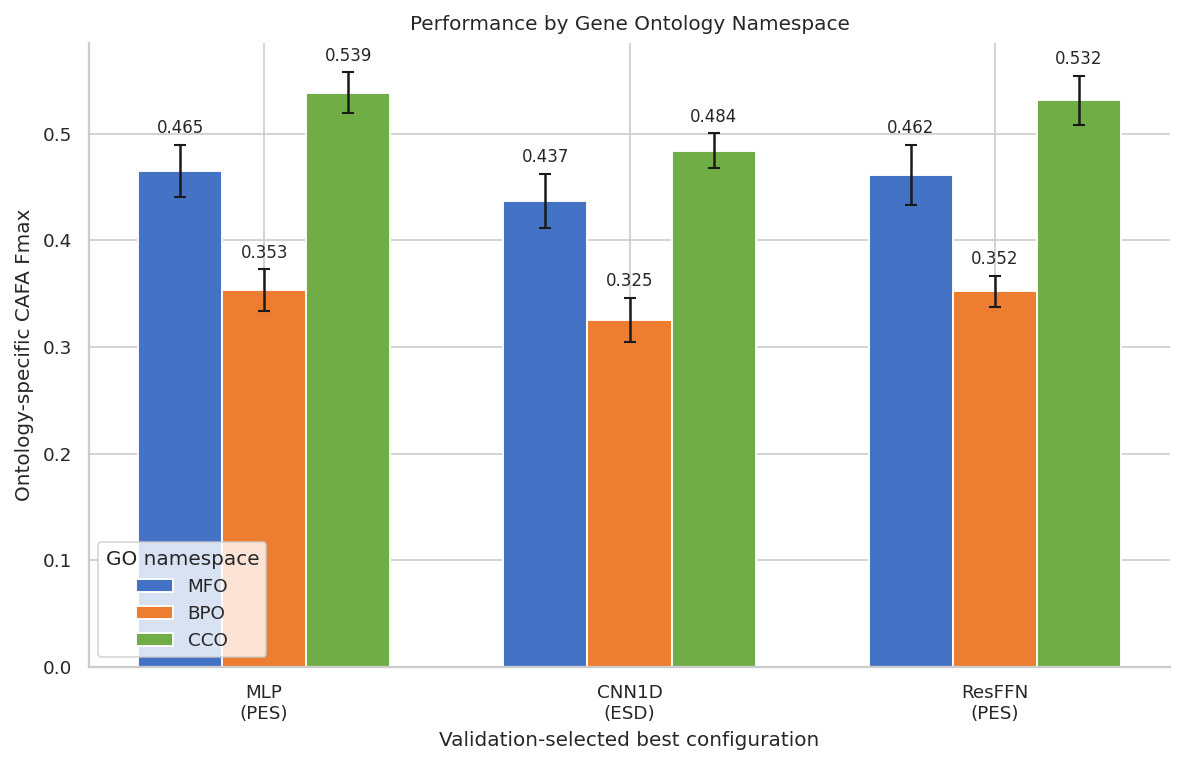

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig5_ontology_breakdown.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig5_ontology_breakdown.pdf


In [7]:
# ============================================================
# Figure 5 — Ontology-specific Fmax
# Uses the validation-selected best feature combination per architecture.
# ============================================================

ontology_info = [
    ("MFO", "MFO_Fmax_mean", "MFO_Fmax_std", "#4472C4"),
    ("BPO", "BPO_Fmax_mean", "BPO_Fmax_std", "#ED7D31"),
    ("CCO", "CCO_Fmax_mean", "CCO_Fmax_std", "#70AD47"),
]

fig, ax = plt.subplots(figsize=(8, 5.2))

x = np.arange(len(ARCH_ORDER))
width = 0.23

for i, (label, mean_col, std_col, color) in enumerate(ontology_info):
    values = best_by_arch[mean_col]
    errors = best_by_arch[std_col]

    bars = ax.bar(
        x + i * width,
        values,
        width,
        yerr=errors,
        capsize=3,
        label=label,
        color=color,
        edgecolor="white",
        linewidth=0.9,
    )

    for bar, value, error in zip(bars, values, errors):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + error + 0.007,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x + width)
ax.set_xticklabels(
    [
        f"{row.Architecture}\n({row.Feature})"
        for _, row in best_by_arch.iterrows()
    ]
)
ax.set_ylabel("Ontology-specific CAFA Fmax")
ax.set_xlabel("Validation-selected best configuration")
ax.set_title("Performance by Gene Ontology Namespace")
ax.legend(title="GO namespace", frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_figure(fig, "Fig5_ontology_breakdown")

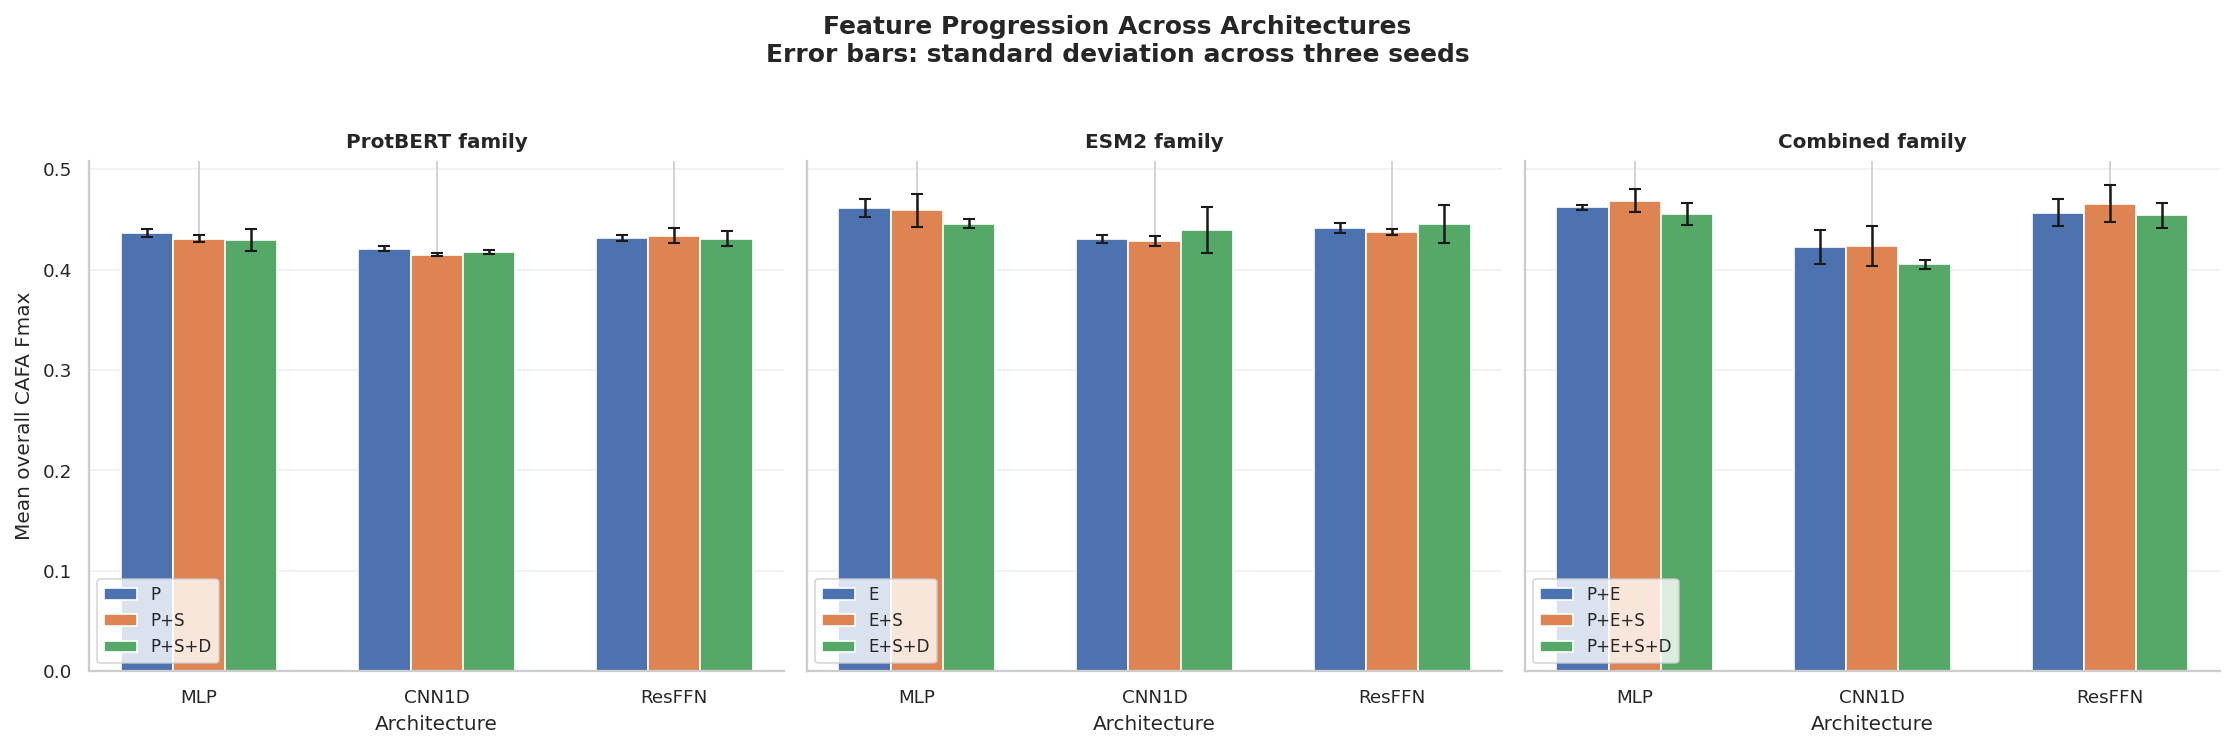

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig6_feature_progression.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig6_feature_progression.pdf


In [8]:
# ============================================================
# Figure 6 — Feature progression within each representation family
# ============================================================

feature_groups = [
    ("ProtBERT family", ["P", "PS", "PSD"], ["P", "P+S", "P+S+D"]),
    ("ESM2 family", ["E", "ES", "ESD"], ["E", "E+S", "E+S+D"]),
    ("Combined family", ["PE", "PES", "PESD"], ["P+E", "P+E+S", "P+E+S+D"]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, (title, features, labels) in zip(axes, feature_groups):
    width = 0.22
    x = np.arange(len(ARCH_ORDER))

    for i, feature in enumerate(features):
        subset = (
            results[results["Feature"] == feature]
            .set_index("Architecture")
            .reindex(ARCH_ORDER)
        )

        bars = ax.bar(
            x + i * width,
            subset["Overall_Fmax_mean"],
            width=width,
            yerr=subset["Overall_Fmax_std"],
            capsize=3,
            label=labels[i],
            edgecolor="white",
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(ARCH_ORDER)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Architecture")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, frameon=True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean overall CAFA Fmax")
fig.suptitle(
    "Feature Progression Across Architectures\n"
    "Error bars: standard deviation across three seeds",
    y=1.03,
    fontsize=12,
    fontweight="bold",
)

fig.tight_layout()
save_figure(fig, "Fig6_feature_progression")

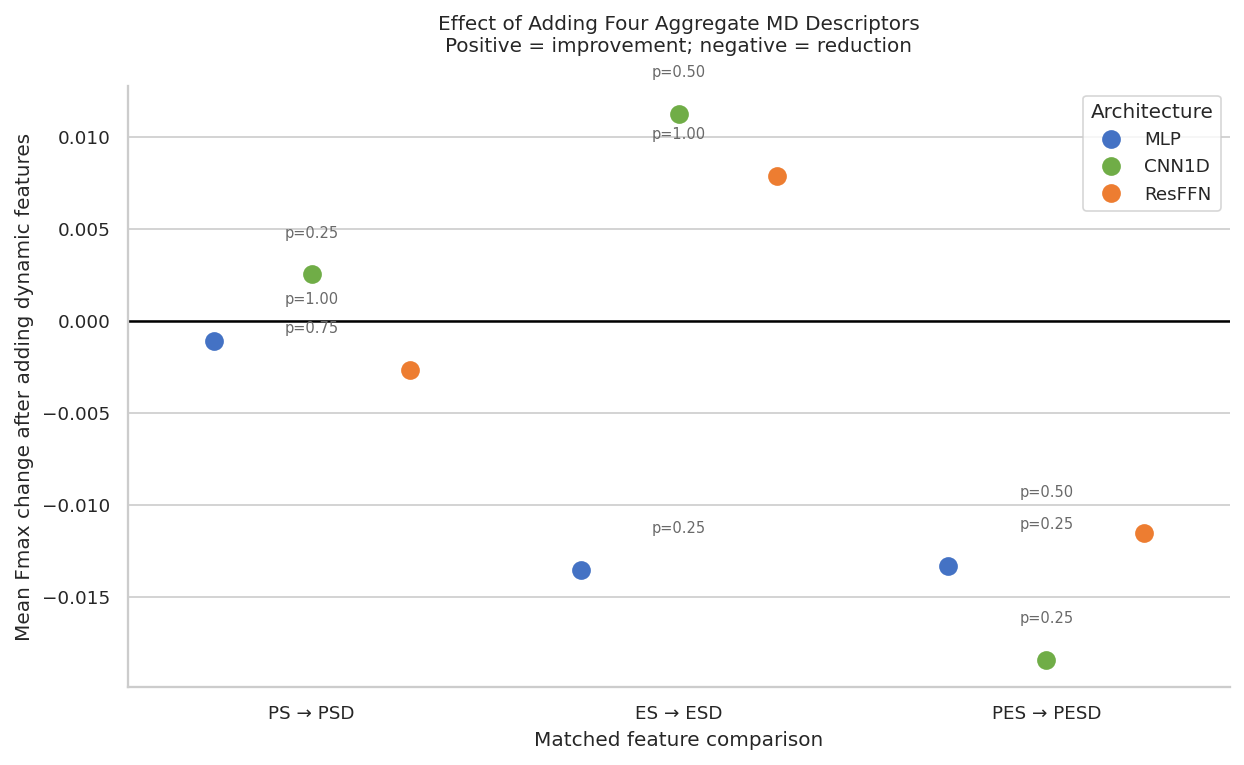

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig7_dynamic_feature_matched_effects.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig7_dynamic_feature_matched_effects.pdf


In [9]:
# ============================================================
# Figure 7 — Matched dynamic-feature effect
# Positive values mean D improved Fmax; negative values mean D reduced Fmax.
# ============================================================

dynamic_plot = dynamic_tests.copy()

comparison_labels = {
    "PSD": "PS → PSD",
    "ESD": "ES → ESD",
    "PESD": "PES → PESD",
}

dynamic_plot["Comparison"] = dynamic_plot["With_dynamic_features"].map(
    comparison_labels
)

fig, ax = plt.subplots(figsize=(8.4, 5.2))

sns.stripplot(
    data=dynamic_plot,
    x="Comparison",
    y="mean_difference_dynamic_minus_no_dynamic",
    hue="Architecture",
    order=["PS → PSD", "ES → ESD", "PES → PESD"],
    hue_order=ARCH_ORDER,
    palette=ARCH_COLORS,
    dodge=True,
    size=9,
    ax=ax,
)

ax.axhline(0, color="black", linewidth=1.2)

for i, row in dynamic_plot.iterrows():
    ax.text(
        ["PS → PSD", "ES → ESD", "PES → PESD"].index(row["Comparison"]),
        row["mean_difference_dynamic_minus_no_dynamic"] + 0.002,
        f"p={row['Wilcoxon_p_value']:.2f}",
        ha="center",
        fontsize=7,
        color="dimgray",
    )

ax.set_xlabel("Matched feature comparison")
ax.set_ylabel("Mean Fmax change after adding dynamic features")
ax.set_title(
    "Effect of Adding Four Aggregate MD Descriptors\n"
    "Positive = improvement; negative = reduction\n"


)
ax.legend(title="Architecture", frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_figure(fig, "Fig7_dynamic_feature_matched_effects")

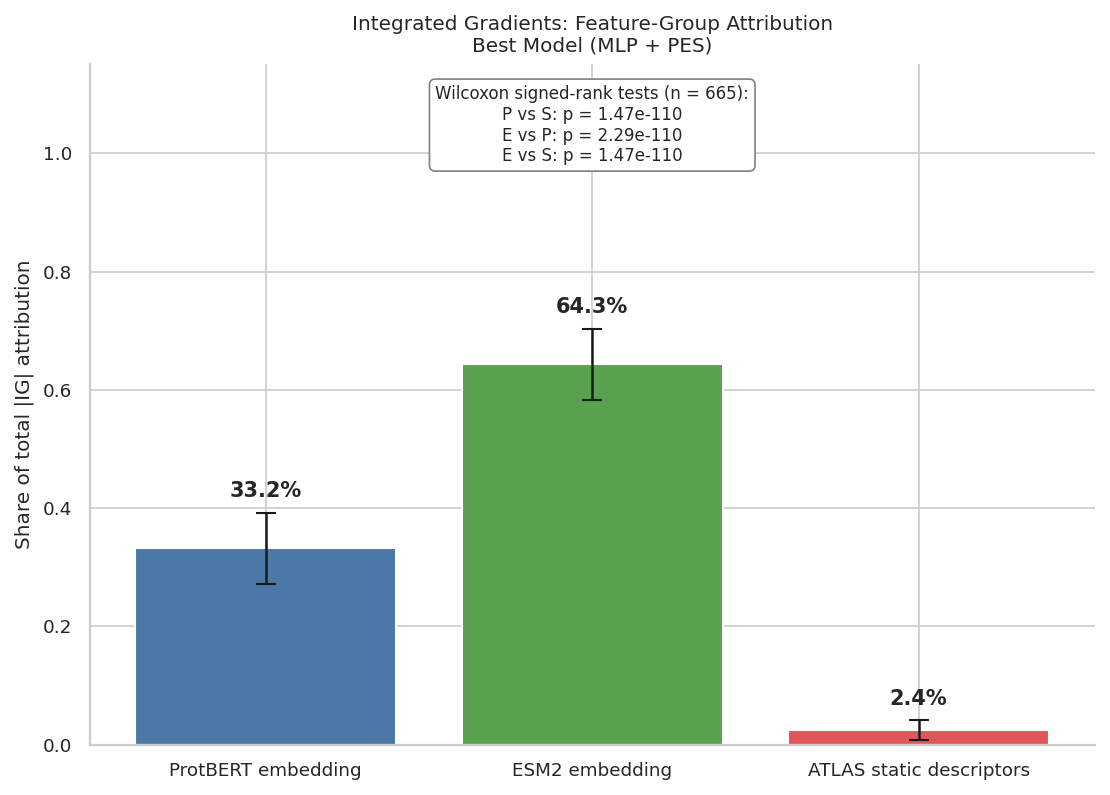

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig8_xai_group_integrated_gradients.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig8_xai_group_integrated_gradients.pdf


In [10]:
# ============================================================
# Figure 8 — Integrated Gradients group importance
# Best final model: MLP + PES (three feature groups: P, E, S)
# ============================================================

xai_summary = (
    xai_group
    .groupby("feature_group")["group_share_of_total_attribution"]
    .agg(["mean", "std", "count"])
    .reindex(["P", "E", "S"])
    .reset_index()
)

group_labels = {
    "P": "ProtBERT embedding",
    "E": "ESM2 embedding",
    "S": "ATLAS static descriptors",
}

xai_summary["label"] = xai_summary["feature_group"].map(group_labels)

# Three pairwise comparisons now exist; report all three.
wilcoxon_lookup = {
    (row.first_group, row.second_group): row.wilcoxon_p_value
    for _, row in xai_wilcoxon.iterrows()
}

fig, ax = plt.subplots(figsize=(7.5, 5.4))

colors = ["#4C78A8", "#59A14F", "#E15759"]

bars = ax.bar(
    xai_summary["label"],
    xai_summary["mean"],
    yerr=xai_summary["std"],
    capsize=5,
    color=colors,
    edgecolor="white",
    linewidth=1.0,
)

for bar, (_, row) in zip(bars, xai_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row["mean"] + row["std"] + 0.02,
        f"{row['mean']:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

p_text = "\n".join(
    f"{a} vs {b}: p = {p:.2e}"
    for (a, b), p in wilcoxon_lookup.items()
)

ax.text(
    0.5,
    0.97,
    f"Wilcoxon signed-rank tests (n = {int(xai_summary['count'].iloc[0])}):\n{p_text}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="gray"),
)

ax.set_ylim(0, 1.15)
ax.set_ylabel("Share of total |IG| attribution")
ax.set_title("Integrated Gradients: Feature-Group Attribution\nBest Model (MLP + PES)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_figure(fig, "Fig8_xai_group_integrated_gradients")


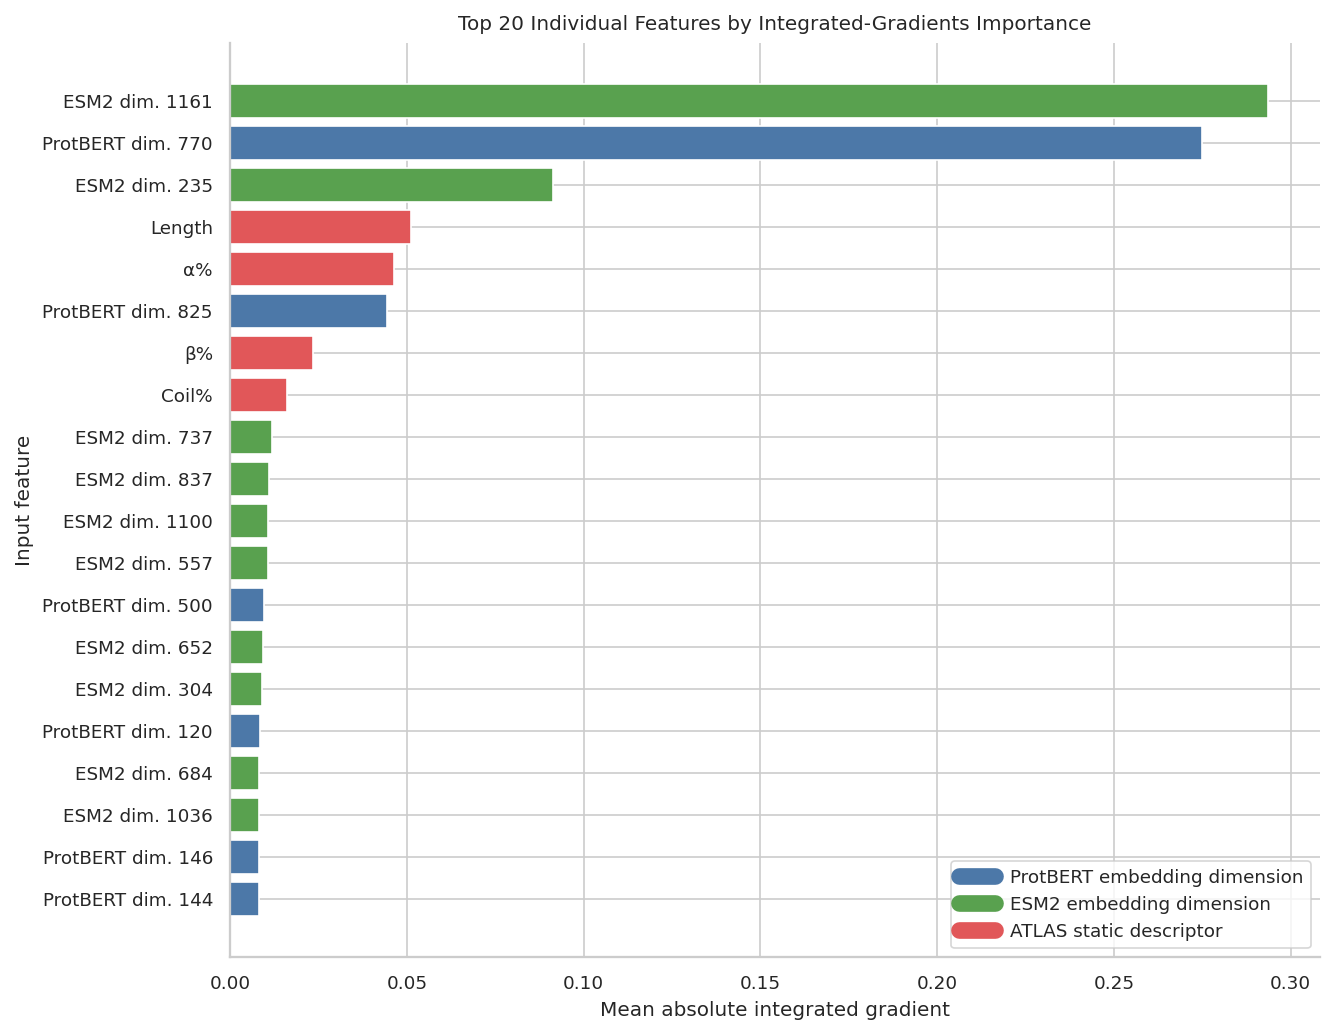

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig9_xai_top_individual_features.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig9_xai_top_individual_features.pdf


In [11]:

# ============================================================
# Figure 9 — Individual-feature Integrated Gradients
# Top 20 features. Layout for PES: P(0-1023), E(1024-2303), S(2304-2307).
# ============================================================

feature_plot = xai_feature.copy()

def feature_label(feature_index):
    feature_index = int(feature_index)

    if feature_index < 1024:
        return f"ProtBERT dim. {feature_index + 1}"
    elif feature_index < 1024 + 1280:
        return f"ESM2 dim. {feature_index - 1024 + 1}"
    else:
        static_position = feature_index - (1024 + 1280)
        return STATIC_FEATURE_NAMES[static_position]

feature_plot["Feature_label"] = feature_plot["feature_index"].apply(feature_label)

top_features = (
    feature_plot
    .sort_values("mean_absolute_integrated_gradient", ascending=False)
    .head(20)
    .sort_values("mean_absolute_integrated_gradient")
)

group_color_map = {"P": "#4C78A8", "E": "#59A14F", "S": "#E15759"}

fig, ax = plt.subplots(figsize=(9, 7))

bar_colors = top_features["feature_group"].map(group_color_map)

ax.barh(
    top_features["Feature_label"],
    top_features["mean_absolute_integrated_gradient"],
    color=bar_colors,
    edgecolor="white",
)

legend_handles = [
    Line2D([0], [0], color="#4C78A8", lw=8, label="ProtBERT embedding dimension"),
    Line2D([0], [0], color="#59A14F", lw=8, label="ESM2 embedding dimension"),
    Line2D([0], [0], color="#E15759", lw=8, label="ATLAS static descriptor"),
]

ax.legend(handles=legend_handles, loc="lower right", frameon=True)
ax.set_xlabel("Mean absolute integrated gradient")
ax.set_ylabel("Input feature")
ax.set_title("Top 20 Individual Features by Integrated-Gradients Importance")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_figure(fig, "Fig9_xai_top_individual_features")



/tmp/ipykernel_3077/3533715760.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(lomo["display_label"], rotation=15, ha="right")


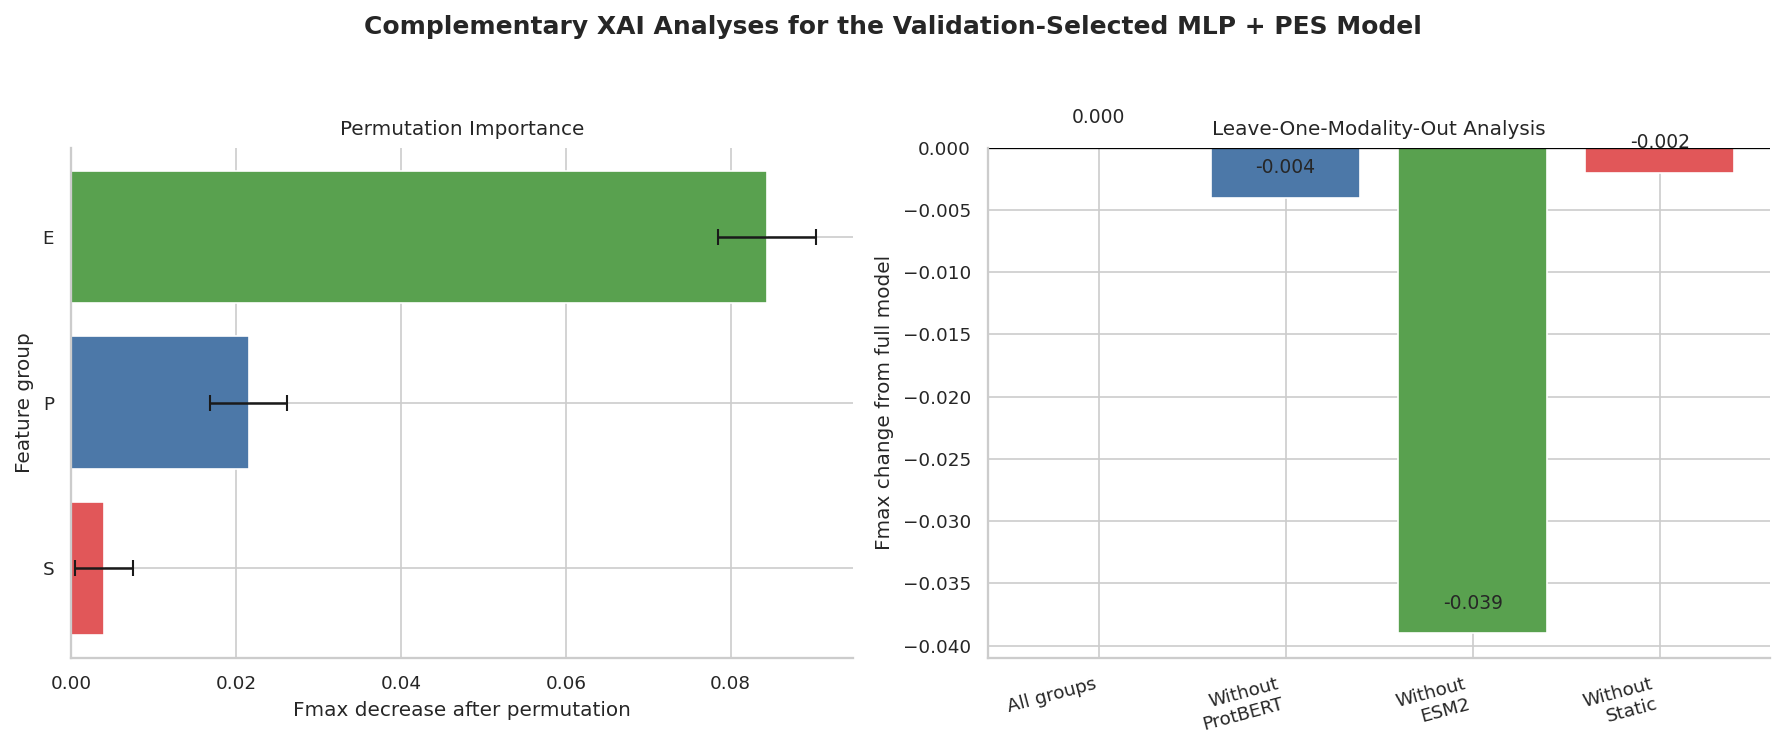

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig10_xai_permutation_and_lomo.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig10_xai_permutation_and_lomo.pdf


In [12]:
# ============================================================
# Figure 10 — Permutation importance and leave-one-modality-out
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

group_color_map2 = {"P": "#4C78A8", "E": "#59A14F", "S": "#E15759"}

# ----- Panel A: permutation importance -----
perm = xai_permutation.copy().sort_values("mean_Fmax_drop")

axes[0].barh(
    perm["feature_group"],
    perm["mean_Fmax_drop"],
    xerr=perm["std_Fmax_drop"],
    capsize=4,
    color=[group_color_map2[g] for g in perm["feature_group"]],
    edgecolor="white",
)

axes[0].set_xlabel("Fmax decrease after permutation")
axes[0].set_ylabel("Feature group")
axes[0].set_title("Permutation Importance")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ----- Panel B: leave-one-modality-out -----
lomo = xai_lomo.copy()

lomo_label_map = {
    "All feature groups": "All groups",
    "Without P": "Without\nProtBERT",
    "Without E": "Without\nESM2",
    "Without S": "Without\nStatic",
}
lomo["display_label"] = lomo["model_input"].map(lomo_label_map)

lomo_bar_colors = ["#9C6ADE"] + [
    group_color_map2[m.replace("Without ", "")]
    for m in lomo["model_input"] if m != "All feature groups"
]

axes[1].bar(
    lomo["display_label"],
    lomo["Fmax_change_from_full"],
    color=lomo_bar_colors,
    edgecolor="white",
)

axes[1].axhline(0, color="black", linewidth=1.1)

for i, (_, row) in enumerate(lomo.iterrows()):
    axes[1].text(
        i,
        row["Fmax_change_from_full"] + 0.002,
        f"{row['Fmax_change_from_full']:.3f}",
        ha="center",
        fontsize=9,
    )

axes[1].set_xticklabels(lomo["display_label"], rotation=15, ha="right")
axes[1].set_ylabel("Fmax change from full model")
axes[1].set_title("Leave-One-Modality-Out Analysis")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle(
    "Complementary XAI Analyses for the Validation-Selected MLP + PES Model",
    y=1.03,
    fontsize=12,
    fontweight="bold",
)

fig.tight_layout()
save_figure(fig, "Fig10_xai_permutation_and_lomo")

/tmp/ipykernel_3077/1803933898.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3077/1803933898.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([namespace_labels[x] for x in namespace_order])


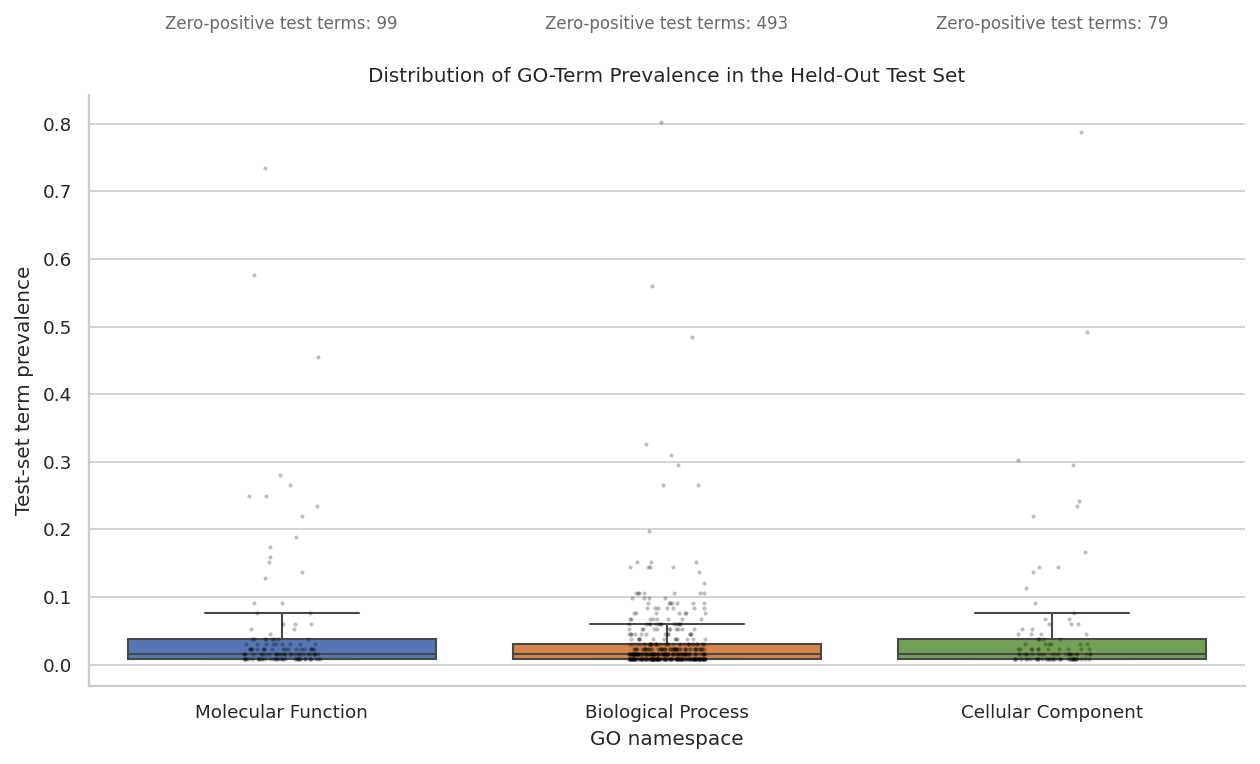

Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig11_test_term_prevalence.png
Saved: /content/drive/MyDrive/atlas-go-revision/results/figures/Fig11_test_term_prevalence.pdf


In [13]:
# ============================================================
# Figure 11 — Test-set GO-term prevalence
# This directly supports the reviewer-requested prevalence analysis.
# ============================================================

positive_prevalence = term_prevalence[
    term_prevalence["test_prevalence"] > 0
].copy()

zero_counts = (
    term_prevalence[term_prevalence["test_prevalence"] == 0]
    .groupby("namespace")
    .size()
    .to_dict()
)

namespace_order = ["MFO", "BPO", "CCO"]
namespace_labels = {
    "MFO": "Molecular Function",
    "BPO": "Biological Process",
    "CCO": "Cellular Component",
}

fig, ax = plt.subplots(figsize=(8.5, 5.2))

sns.boxplot(
    data=positive_prevalence,
    x="namespace",
    y="test_prevalence",
    order=namespace_order,
    palette=["#4472C4", "#ED7D31", "#70AD47"],
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=positive_prevalence.sample(
        min(700, len(positive_prevalence)),
        random_state=42,
    ),
    x="namespace",
    y="test_prevalence",
    order=namespace_order,
    color="black",
    alpha=0.25,
    size=2,
    ax=ax,
)

ax.set_xticklabels([namespace_labels[x] for x in namespace_order])
ax.set_xlabel("GO namespace")
ax.set_ylabel("Test-set term prevalence")

for position, namespace in enumerate(namespace_order):
    zero_number = zero_counts.get(namespace, 0)

    ax.text(
        position,
        0.94,
        f"Zero-positive test terms: {zero_number}",
        ha="center",
        fontsize=8,
        color="dimgray",
    )

ax.set_title("Distribution of GO-Term Prevalence in the Held-Out Test Set")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_figure(fig, "Fig11_test_term_prevalence")

In [14]:
# ============================================================
# Final check
# ============================================================

print("=" * 65)
print("UPDATED FIGURES COMPLETE")
print("=" * 65)

for filename in sorted(os.listdir(FIGURES_DIR)):
    if filename.endswith(".png"):
        print(filename)

UPDATED FIGURES COMPLETE
Fig10_xai_permutation_and_lomo.png
Fig11_test_term_prevalence.png
Fig1_best_architecture_comparison.png
Fig2_feature_ablation_heatmap.png
Fig3_representation_family_comparison.png
Fig4_fmax_auprc_all_configurations.png
Fig5_ontology_breakdown.png
Fig6_feature_progression.png
Fig7_dynamic_feature_matched_effects.png
Fig8_xai_group_integrated_gradients.png
Fig9_xai_top_individual_features.png
xai_integrated_gradients_per_feature.png
xai_permutation_importance.png
